In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Setup complete.')

Setup complete.


In [35]:
df = pd.read_csv('plant_health_data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1200, 14)


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


In [36]:
print('Columns:')
print(df.columns.tolist())
print()
print('Data types:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

Columns:
['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status']

Data types:
Timestamp                  object
Plant_ID                    int64
Soil_Moisture             float64
Ambient_Temperature       float64
Soil_Temperature          float64
Humidity                  float64
Light_Intensity           float64
Soil_pH                   float64
Nitrogen_Level            float64
Phosphorus_Level          float64
Potassium_Level           float64
Chlorophyll_Content       float64
Electrochemical_Signal    float64
Plant_Health_Status        object
dtype: object

Missing values:
Timestamp                 0
Plant_ID                  0
Soil_Moisture             0
Ambient_Temperature       0
Soil_Temperature          0
Humidity                  0
Light_Intensity           0
Soil_pH           

Target class distribution:
Plant_Health_Status
High Stress        500
Moderate Stress    401
Healthy            299
Name: count, dtype: int64



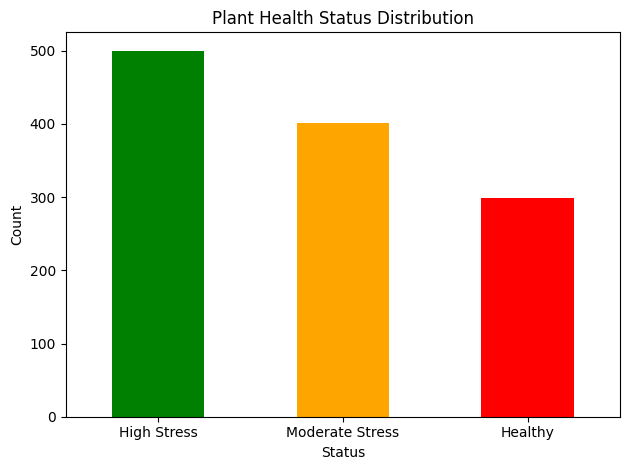

In [37]:
print('Target class distribution:')
print(df['Plant_Health_Status'].value_counts())
print()
df['Plant_Health_Status'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Plant Health Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [38]:
df.describe()

,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,5.500000,25.106918,23.999130,19.957794,54.853165,612.637265,6.524102,30.106751,30.264484,30.112088,34.749591,0.987764
std,2.873479,8.677725,3.441561,2.932073,8.784916,228.318853,0.581755,11.514396,11.466846,11.668085,8.766995,0.575116
min,1.000000,10.000724,18.001993,15.003710,40.028758,200.615482,5.507392,10.003650,10.017690,10.000606,20.025511,0.002376
25%,3.000000,17.131893,21.101766,17.353027,47.019694,416.878983,6.026042,20.249774,20.894445,19.585561,27.463350,0.487982
50%,5.500000,25.168333,23.889044,19.911473,54.692069,617.240221,6.540524,30.138590,30.019385,30.495054,34.433427,0.981647
75%,8.000000,32.370231,27.042634,22.596851,62.451053,811.474690,7.030039,40.184737,40.131459,40.108296,42.232637,1.473142
max,10.000000,39.993164,29.990886,24.995929,69.968871,999.856262,7.497823,49.951136,49.980700,49.981945,49.990811,1.996116


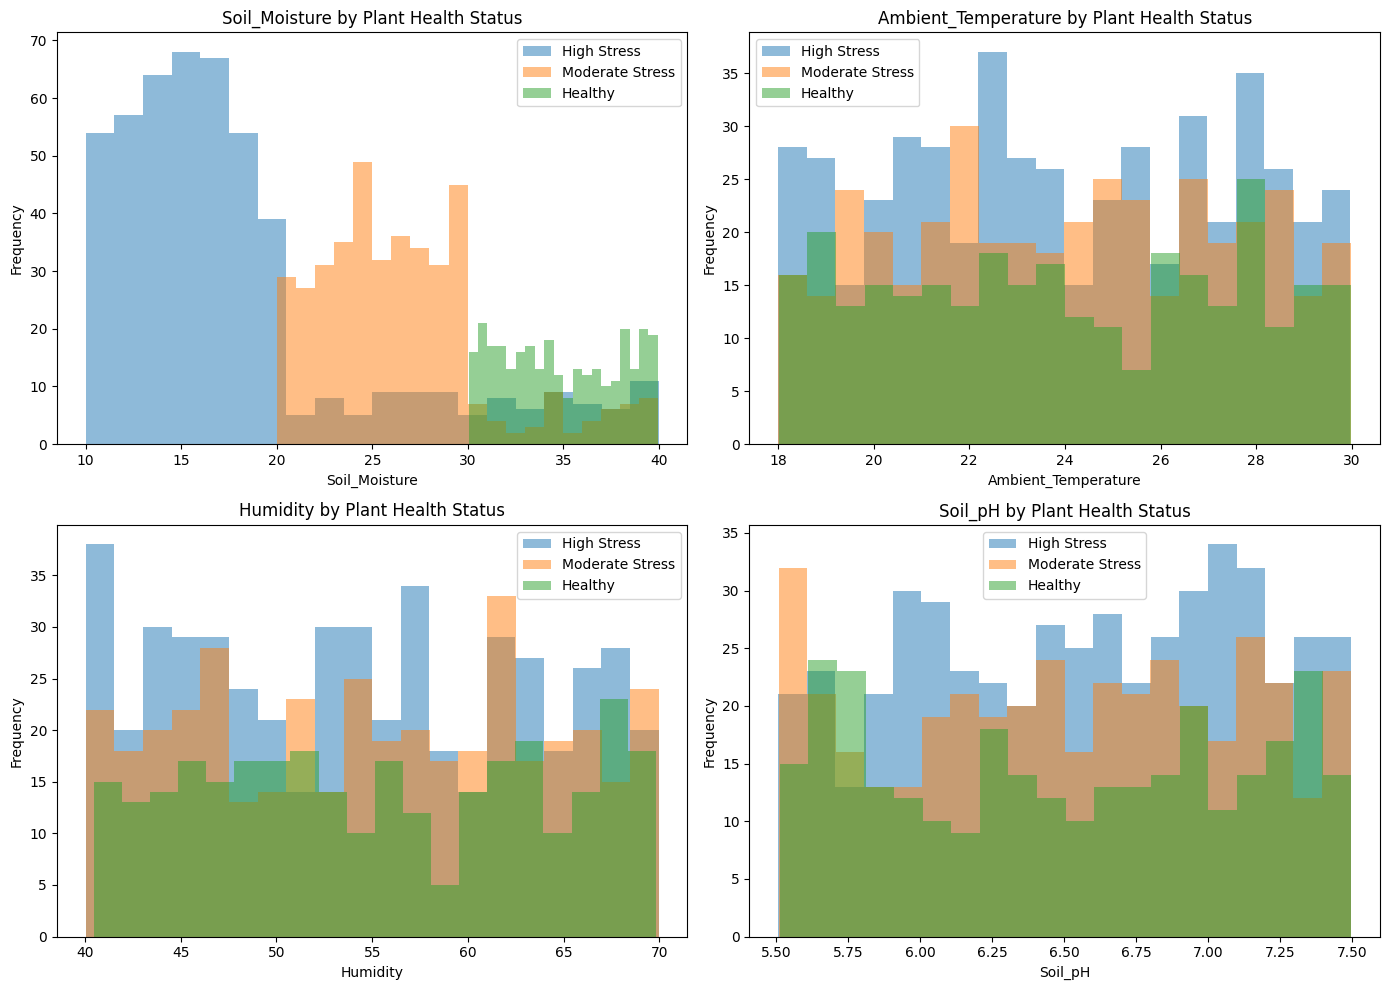

In [39]:
# Feature distribution by class
features_to_plot = ['Soil_Moisture', 'Ambient_Temperature', 'Humidity', 'Soil_pH']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    for status in df['Plant_Health_Status'].unique():
        subset = df[df['Plant_Health_Status'] == status]
        axes[i].hist(subset[feature], bins=20, alpha=0.5, label=status)
    axes[i].set_title(f'{feature} by Plant Health Status')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.savefig('feature_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

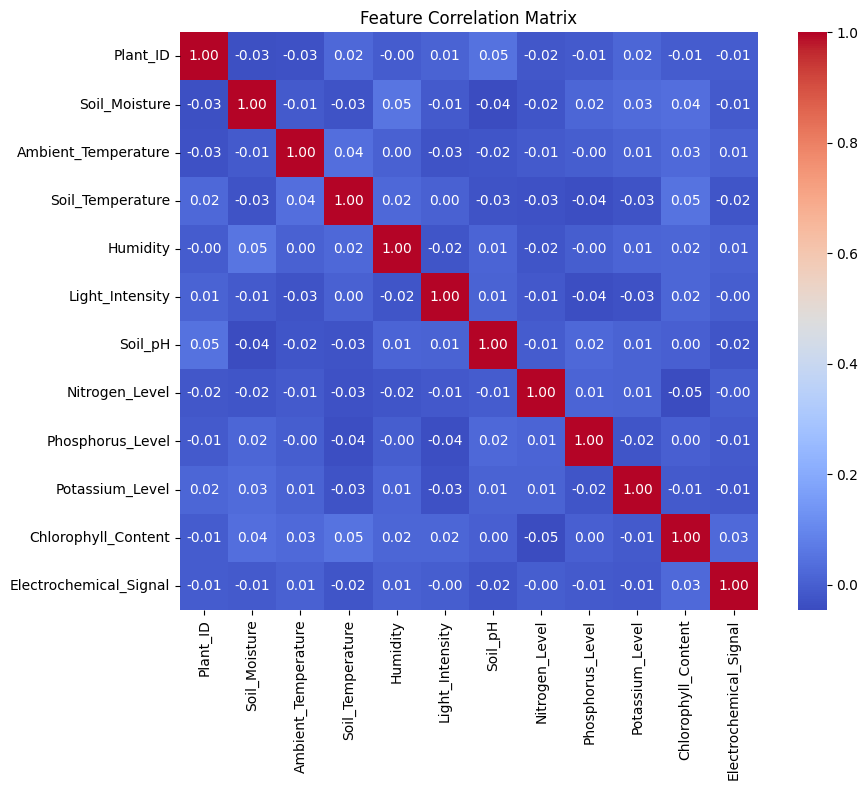

In [40]:
# Correlation heatmap (numeric features only)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [41]:
FEATURES = ['Soil_Moisture', 'Ambient_Temperature', 'Humidity', 'Soil_pH']
TARGET = 'Plant_Health_Status'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print()
print('Feature ranges:')
print(X.describe().loc[['min', 'max', 'mean']])
print()
print('Classes:')
print(y.unique())

X shape: (1200, 4)
y shape: (1200,)

Feature ranges:
      Soil_Moisture  Ambient_Temperature   Humidity   Soil_pH
min       10.000724            18.001993  40.028758  5.507392
max       39.993164            29.990886  69.968871  7.497823
mean      25.106918            23.999130  54.853165  6.524102

Classes:
['High Stress' 'Moderate Stress' 'Healthy']


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class distribution:')
print(y_train.value_counts(normalize=True).round(3))
print(f'Test class distribution:')
print(y_test.value_counts(normalize=True).round(3))

Train: (960, 4), Test: (240, 4)
Train class distribution:
Plant_Health_Status
High Stress        0.417
Moderate Stress    0.334
Healthy            0.249
Name: proportion, dtype: float64
Test class distribution:
Plant_Health_Status
High Stress        0.417
Moderate Stress    0.333
Healthy            0.250
Name: proportion, dtype: float64


In [43]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'SVM': SVC(random_state=RANDOM_SEED),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    print(f'{name:20s}  train={train_acc:.4f}  test={test_acc:.4f}  cv={cv_scores.mean():.4f}+/-{cv_scores.std():.4f}')

results_df = pd.DataFrame(results).T
results_df

Random Forest         train=1.0000  test=0.8292  cv=0.8677+/-0.0397
Gradient Boosting     train=0.9385  test=0.8417  cv=0.8667+/-0.0391
Decision Tree         train=1.0000  test=0.7458  cv=0.7927+/-0.0214
Logistic Regression   train=0.7635  test=0.7000  cv=0.7531+/-0.0526
SVM                   train=0.8396  test=0.7958  cv=0.8385+/-0.0436
KNN                   train=0.8688  test=0.7917  cv=0.8333+/-0.0410


,train_acc,test_acc,cv_mean,cv_std
Random Forest,1.000000,0.829167,0.867708,0.039747
Gradient Boosting,0.938542,0.841667,0.866667,0.039059
Decision Tree,1.000000,0.745833,0.792708,0.021449
Logistic Regression,0.763542,0.700000,0.753125,0.052560
SVM,0.839583,0.795833,0.838542,0.043576
KNN,0.868750,0.791667,0.833333,0.041010


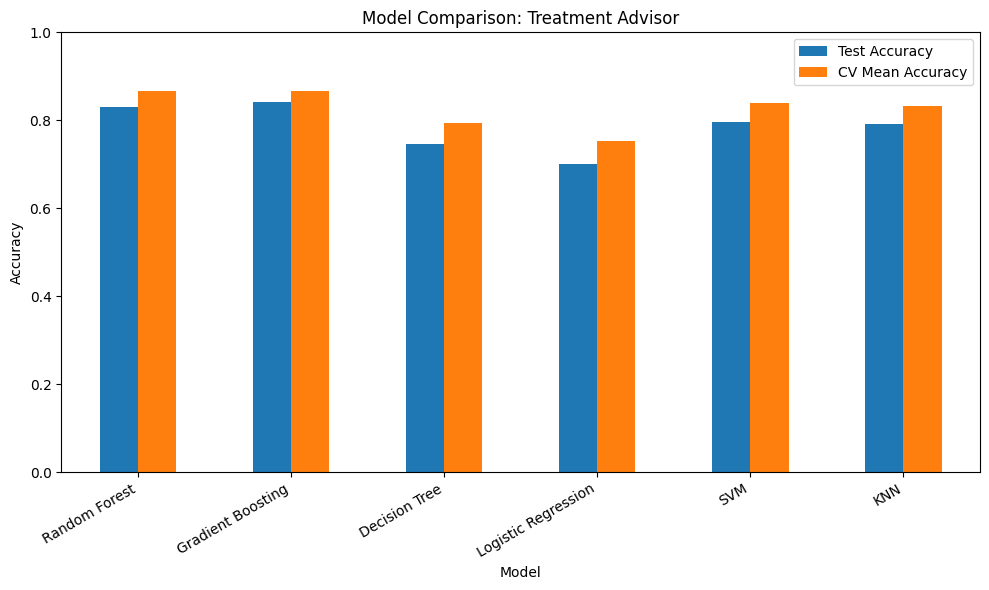

In [44]:
# Bar chart compare models
fig, ax = plt.subplots(figsize=(10, 6))
results_df[['test_acc', 'cv_mean']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison: Treatment Advisor')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Model')
ax.set_ylim(0, 1.0)
ax.legend(['Test Accuracy', 'CV Mean Accuracy'])
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [45]:
final_model = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=RANDOM_SEED)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f'Final test accuracy: {test_acc:.4f}')
print()
print('Classification report:')
print(classification_report(y_test, y_pred))

Final test accuracy: 0.8333

Classification report:
                 precision    recall  f1-score   support

        Healthy       0.73      0.93      0.82        60
    High Stress       0.97      0.73      0.83       100
Moderate Stress       0.81      0.89      0.85        80

       accuracy                           0.83       240
      macro avg       0.84      0.85      0.83       240
   weighted avg       0.86      0.83      0.83       240



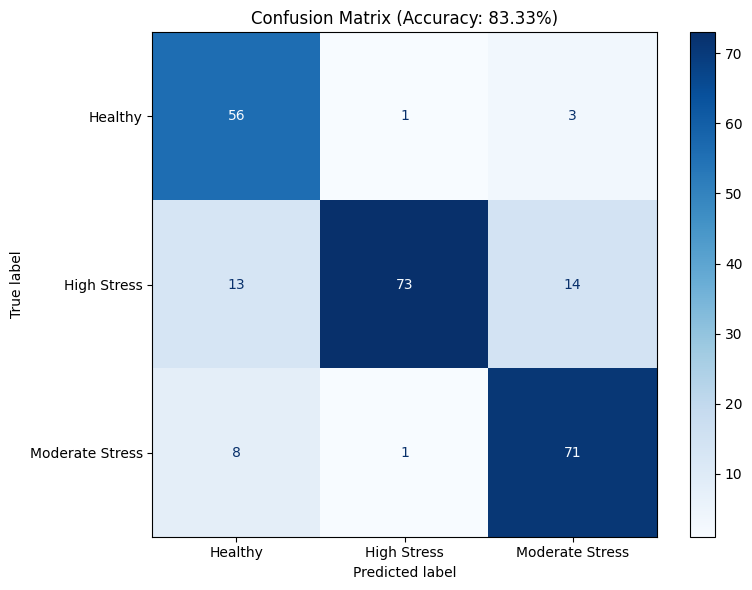

In [46]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix (Accuracy: {test_acc:.2%})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

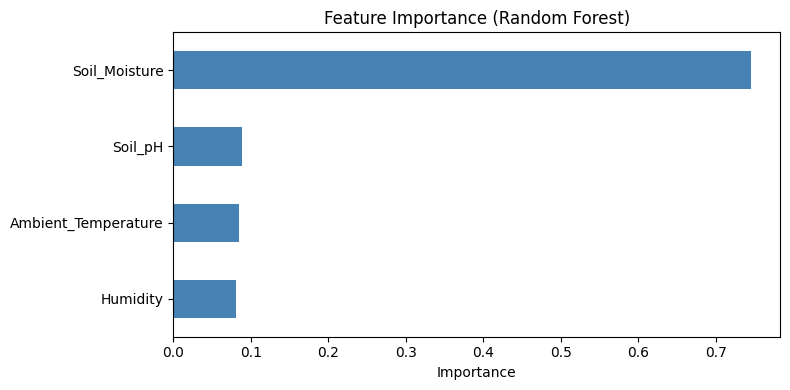

Humidity               0.080553
Ambient_Temperature    0.084962
Soil_pH                0.088646
Soil_Moisture          0.745839
dtype: float64


In [47]:
# Feature importance
importances = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print(importances)

In [48]:
# Treatment advice in English and Arabic
treatment_advice = {
    'Healthy': {
        'en': 'Plant is healthy. Continue current irrigation and monitoring schedule.',
        'ar': 'النبات بصحة جيدة. استمر في جدول الري والمراقبة الحالي.'
    },
    'Moderate Stress': {
        'en': 'Plant is under moderate stress. Check soil moisture and consider light irrigation. Inspect for early signs of disease.',
        'ar': 'النبات يعاني من ضغط متوسط. تحقق من رطوبة التربة وفكر في الري الخفيف. افحص العلامات المبكرة للمرض.'
    },
    'High Stress': {
        'en': 'Plant is under high stress. Irrigate immediately, reduce sun exposure with shade cloth, and check pH balance. Consider soil treatment.',
        'ar': 'النبات في حالة ضغط حاد. اروي على الفور، قلل التعرض للشمس بقماش التظليل، وتحقق من توازن الأس الهيدروجيني. فكر في معالجة التربة.'
    }
}

# Save model
with open('treatment_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save treatment advice
with open('treatment_advice.json', 'w', encoding='utf-8') as f:
    json.dump(treatment_advice, f, ensure_ascii=False, indent=2)

# Save feature names (for inference safety)
with open('treatment_features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

print('Saved:')
print('  treatment_model.pkl')
print('  treatment_advice.json')
print('  treatment_features.json')

Saved:
  treatment_model.pkl
  treatment_advice.json
  treatment_features.json


In [49]:
# Load saved artifacts (verify they work)
with open('treatment_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('treatment_advice.json', 'r', encoding='utf-8') as f:
    loaded_advice = json.load(f)
with open('treatment_features.json', 'r') as f:
    loaded_features = json.load(f)

def predict_treatment(moisture, temperature, humidity, pH, lang='en'):
    """Predict plant health status and return treatment advice.
    
    Args:
        moisture: soil moisture, percent
        temperature: ambient temperature, Celsius
        humidity: relative humidity, percent
        pH: soil pH (use 6.5 default if no pH sensor)
        lang: 'en' or 'ar'
    """
    X_input = pd.DataFrame([[moisture, temperature, humidity, pH]], columns=loaded_features)
    status = loaded_model.predict(X_input)[0]
    confidence = loaded_model.predict_proba(X_input).max()
    advice = loaded_advice[status][lang]
    return {
        'status': status,
        'confidence': float(confidence),
        'advice': advice,
        'language': lang
    }

# Test case 1: healthy conditions
print('Test 1 (healthy):')
print(predict_treatment(moisture=60, temperature=24, humidity=65, pH=6.5, lang='en'))
print(predict_treatment(moisture=60, temperature=24, humidity=65, pH=6.5, lang='ar'))
print()

# Test case 2: high stress (dry, hot, acidic)
print('Test 2 (high stress):')
print(predict_treatment(moisture=15, temperature=42, humidity=20, pH=4.5, lang='en'))
print(predict_treatment(moisture=15, temperature=42, humidity=20, pH=4.5, lang='ar'))
print()

# Test case 3: moderate stress
print('Test 3 (moderate stress):')
print(predict_treatment(moisture=35, temperature=33, humidity=40, pH=6.0, lang='en'))

Test 1 (healthy):
{'status': 'Moderate Stress', 'confidence': 0.35, 'advice': 'Plant is under moderate stress. Check soil moisture and consider light irrigation. Inspect for early signs of disease.', 'language': 'en'}
{'status': 'Moderate Stress', 'confidence': 0.35, 'advice': 'النبات يعاني من ضغط متوسط. تحقق من رطوبة التربة وفكر في الري الخفيف. افحص العلامات المبكرة للمرض.', 'language': 'ar'}

Test 2 (high stress):
{'status': 'High Stress', 'confidence': 0.915, 'advice': 'Plant is under high stress. Irrigate immediately, reduce sun exposure with shade cloth, and check pH balance. Consider soil treatment.', 'language': 'en'}
{'status': 'High Stress', 'confidence': 0.915, 'advice': 'النبات في حالة ضغط حاد. اروي على الفور، قلل التعرض للشمس بقماش التظليل، وتحقق من توازن الأس الهيدروجيني. فكر في معالجة التربة.', 'language': 'ar'}

Test 3 (moderate stress):
{'status': 'Moderate Stress', 'confidence': 0.45, 'advice': 'Plant is under moderate stress. Check soil moisture and consider light irr

## 10. Flask endpoint code (copy into your AI service)

Add this to your existing Flask file alongside the disease and crop endpoints:

```python
import pickle, json
import pandas as pd
from flask import request, jsonify

# Load at startup
treatment_model = pickle.load(open('models/treatment_model.pkl', 'rb'))
treatment_advice = json.load(open('models/treatment_advice.json', encoding='utf-8'))
treatment_features = json.load(open('models/treatment_features.json'))

@app.route('/predict-treatment', methods=['POST'])
def predict_treatment_endpoint():
    data = request.json
    lang = data.get('lang', 'en')
    X_input = pd.DataFrame([[
        data['moisture'],
        data['temperature'],
        data['humidity'],
        data.get('pH', 6.5)
    ]], columns=treatment_features)
    status = treatment_model.predict(X_input)[0]
    confidence = float(treatment_model.predict_proba(X_input).max())
    advice = treatment_advice[status][lang]
    return jsonify({
        'status': status,
        'confidence': confidence,
        'advice': advice,
        'language': lang
    })
```

## 11. Summary

- Dataset: Plant Health Data from Kaggle
- Features used: Soil_Moisture, Ambient_Temperature, Humidity, Soil_pH
- Target: Plant_Health_Status (Healthy / Moderate Stress / High Stress)
- Best model: Random Forest
- Output: bilingual treatment advice (English + Arabic)
- Saved artifacts: `treatment_model.pkl`, `treatment_advice.json`, `treatment_features.json`

Drop the three files in the AI service `models/` folder and add the Flask endpoint code in section 10.